# Farthest-Point Sampling and Voronoi Diagrams

Given a domain $\Omega$ and a budget of $k$ points, how should we place them so that no part of $\Omega$ is too far from a sample? This **covering** or **dispersion** problem appears throughout computer graphics, computational geometry, numerical integration, and machine learning.

## Farthest-point sampling

**Farthest-point sampling** (FPS) is a greedy algorithm that builds a well-spread point set incrementally:

1. Initialize $\mathcal{P} = \{p_1\}$ (any seed point).
2. At each step, add the point $p^* \in \Omega$ that **maximizes the distance to the current set**:
$$
p_{k+1} = \arg\max_{q \in \Omega} \, d(q,\, \mathcal{P}_k), \qquad d(q, \mathcal{P}) = \min_{p \in \mathcal{P}} d(q, p).
$$
3. Repeat until the desired number of points is reached.

The key property is that FPS produces a **$2$-approximation** of the optimal $k$-center problem: the covering radius $\max_{q \in \Omega} d(q, \mathcal{P}_k)$ is at most twice the optimal. Moreover, at each step, the farthest distance decreases monotonically, giving a principled sequence of increasingly dense samplings.

## Weighted farthest-point sampling

We can bias sampling toward regions with high density $w(q) > 0$ by using a **weighted distance**:
$$
d_w(q, p) = \frac{\|q - p\|}{w(q)},
$$
or equivalently by maximizing $\min_p \|q - p\| \cdot w(q)$. This allows more samples to be placed in high-weight regions.

## Voronoi diagram

At any step, the **Voronoi diagram** of $\mathcal{P}_k$ partitions $\Omega$ into cells, where each cell contains all points closest to one particular sample:
$$
V(p_i) = \{q \in \Omega : d(q, p_i) \leq d(q, p_j) \;\forall j \neq i\}.
$$
FPS always places the next point at the **center of the largest Voronoi cell** (in the minimax sense), ensuring cells shrink as evenly as possible.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ipywidgets import interact, IntSlider

plt.rcParams["figure.dpi"] = 120

## Farthest-point sampling on a uniform grid

We implement FPS on a 2D grid using vectorized distance computations. The algorithm maintains an array `D[q]` = distance from grid point $q$ to the nearest already-selected sample. After adding a new point, we update this array in a single pass.

In [2]:
def farthest_point_sampling(n_grid, n_pts, weight_img=None, seed=(0, 0)):
    """
    Greedy farthest-point sampling on an n_grid x n_grid domain.
    weight_img: optional positive array of shape (n_grid, n_grid).
                Larger weights attract more samples.
    Returns:
        pts: (n_pts, 2) integer pixel coordinates
        voronoi: (n_grid, n_grid) int array, Voronoi cell index for each pixel
        dist_seq: (n_pts,) covering radius at each step
    """
    Y, X = np.meshgrid(np.arange(n_grid), np.arange(n_grid), indexing='ij')
    flat_y = Y.ravel()  # shape (n_grid^2,)
    flat_x = X.ravel()

    if weight_img is None:
        weight_img = np.ones((n_grid, n_grid))
    w_flat = weight_img.ravel()  # weights at each grid point

    pts = [seed]
    # Distance from each grid point to its nearest sample
    py, px = seed
    d2 = (flat_y - py)**2 + (flat_x - px)**2
    # weighted: distance / weight, so high-weight points appear "closer"
    d_eff = d2.astype(float) / (w_flat ** 2)
    voronoi = np.zeros(n_grid * n_grid, dtype=int)
    dist_seq = [np.sqrt(d2.max())]

    for k in range(1, n_pts):
        j_new = int(np.argmax(d_eff))
        py_new, px_new = flat_y[j_new], flat_x[j_new]
        pts.append((py_new, px_new))

        d2_new = (flat_y - py_new)**2 + (flat_x - px_new)**2
        d_eff_new = d2_new.astype(float) / (w_flat ** 2)

        closer = d_eff_new < d_eff
        d_eff[closer] = d_eff_new[closer]
        voronoi[closer] = k
        dist_seq.append(np.sqrt(d2[np.argmax(d_eff)]))  # geometric distance to nearest

    voronoi_2d = voronoi.reshape(n_grid, n_grid)
    return np.array(pts), voronoi_2d, np.array(dist_seq)


print("FPS ready.")

FPS ready.


## Voronoi diagrams at successive stages

We run FPS on a $200 \times 200$ uniform grid and visualize the Voronoi diagram after $k = 5, 15, 50, 200$ points. Each Voronoi cell is colored by its index and overlaid with the sample positions. Observe how the cells grow more uniform as $k$ increases — FPS minimizes the maximum cell diameter.

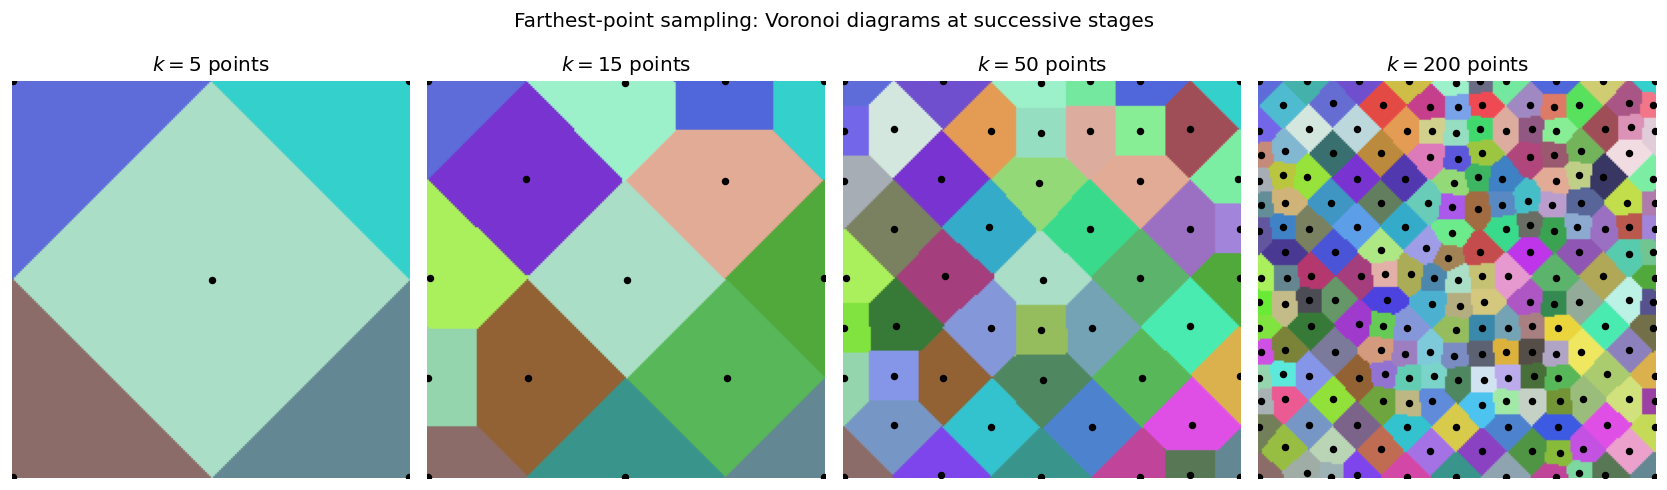

In [3]:
n_grid = 200
n_total = 200
pts_all, vor_all, dist_seq = farthest_point_sampling(n_grid, n_total, seed=(n_grid//2, n_grid//2))

# Recolor: recompute Voronoi for each subset size
def voronoi_subset(pts, n_grid):
    """Exact Voronoi labelling for a subset of points."""
    Y, X = np.meshgrid(np.arange(n_grid), np.arange(n_grid), indexing='ij')
    flat_y = Y.ravel(); flat_x = X.ravel()
    n_pts = len(pts)
    best_d = np.full(n_grid*n_grid, np.inf)
    best_i = np.zeros(n_grid*n_grid, dtype=int)
    for k, (py, px) in enumerate(pts):
        d2 = (flat_y - py)**2 + (flat_x - px)**2
        closer = d2 < best_d
        best_d[closer] = d2[closer]
        best_i[closer] = k
    return best_i.reshape(n_grid, n_grid)

# Fixed color map for up to 200 cells
rng_col = np.random.default_rng(7)
cell_colors = rng_col.uniform(0.2, 0.95, size=(n_total, 3))

stages = [5, 15, 50, 200]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, k in zip(axes, stages):
    pts_k = pts_all[:k]
    vor_k = voronoi_subset(pts_k, n_grid)
    img = cell_colors[vor_k]   # (n_grid, n_grid, 3)
    ax.imshow(img, origin='upper')
    ax.scatter(pts_k[:, 1], pts_k[:, 0], s=12, c='k', zorder=5)
    ax.set_title(f"$k = {k}$ points")
    ax.axis('off')

fig.suptitle("Farthest-point sampling: Voronoi diagrams at successive stages", y=1.02)
plt.tight_layout()
plt.show()

## Covering radius decay

The **covering radius** $R_k = \max_{q \in \Omega} d(q, \mathcal{P}_k)$ measures how well the current set covers the domain. It decreases monotonically by construction: each new point reduces the worst-case coverage gap. For a $d$-dimensional domain we expect $R_k \sim k^{-1/d}$, so in 2D: $R_k \sim k^{-1/2}$.

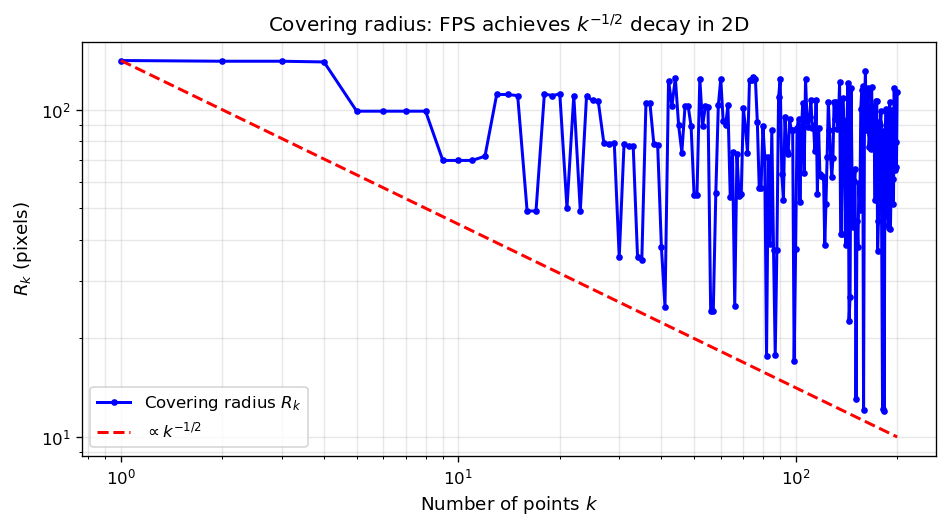

In [4]:
k_range = np.arange(1, len(dist_seq) + 1)
# Theoretical k^{-1/2} scaling (normalized)
scale = dist_seq[0]
theory = scale / np.sqrt(k_range)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(k_range, dist_seq, 'b-o', ms=3, lw=1.8, label="Covering radius $R_k$")
ax.loglog(k_range, theory, 'r--', lw=1.8, label=r"$\propto k^{-1/2}$")
ax.set_xlabel("Number of points $k$", fontsize=11)
ax.set_ylabel("$R_k$ (pixels)", fontsize=11)
ax.set_title("Covering radius: FPS achieves $k^{-1/2}$ decay in 2D")
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Weighted sampling on a non-uniform density

By weighting the distance with an image-derived function $w(q)$, FPS concentrates samples in high-weight regions. Here we use a smooth synthetic density (a sum of Gaussians) and compare uniform vs weighted FPS.

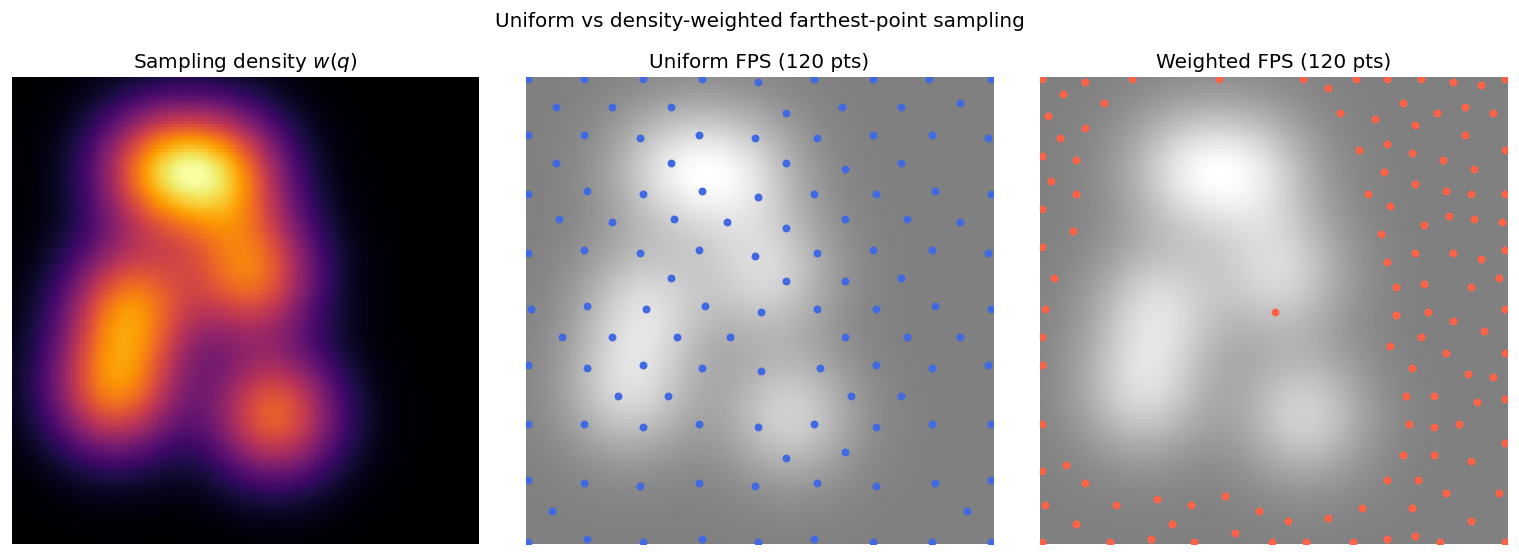

In [5]:
# Build synthetic density: sum of Gaussians at random centers
n_g = 150
rng2 = np.random.default_rng(3)
centers = rng2.uniform(20, n_g-20, size=(6, 2))

Y, X = np.meshgrid(np.arange(n_g), np.arange(n_g), indexing='ij')
density = np.zeros((n_g, n_g))
for cy, cx in centers:
    density += np.exp(-((Y - cy)**2 + (X - cx)**2) / (2 * 15**2))
density = density / density.max()

# Clip very small values to avoid division issues
w_img = np.clip(density, 0.05, 1.0)

n_pts = 120
pts_unif, vor_unif, _ = farthest_point_sampling(n_g, n_pts, weight_img=None,
                                                 seed=(n_g//2, n_g//2))
pts_wt,   vor_wt,   _ = farthest_point_sampling(n_g, n_pts, weight_img=w_img,
                                                 seed=(n_g//2, n_g//2))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

axes[0].imshow(density, cmap='inferno', origin='upper')
axes[0].set_title("Sampling density $w(q)$"); axes[0].axis('off')

axes[1].imshow(density, cmap='gray', origin='upper', alpha=0.5)
axes[1].scatter(pts_unif[:, 1], pts_unif[:, 0], s=14, c='royalblue', zorder=5)
axes[1].set_title(f"Uniform FPS ({n_pts} pts)"); axes[1].axis('off')

axes[2].imshow(density, cmap='gray', origin='upper', alpha=0.5)
axes[2].scatter(pts_wt[:, 1], pts_wt[:, 0], s=14, c='tomato', zorder=5)
axes[2].set_title(f"Weighted FPS ({n_pts} pts)"); axes[2].axis('off')

fig.suptitle("Uniform vs density-weighted farthest-point sampling", y=1.02)
plt.tight_layout()
plt.show()

## Interactive: watch FPS grow step by step

The slider controls how many points have been added. Watch how each new point is placed at the center of the largest Voronoi cell, progressively filling the domain.

In [6]:
def show_fps(k=10):
    pts_k = pts_all[:k]
    vor_k = voronoi_subset(pts_k, n_grid)
    img = cell_colors[vor_k]

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    axes[0].imshow(img, origin='upper')
    axes[0].scatter(pts_k[:-1, 1], pts_k[:-1, 0], s=20, c='k', zorder=5)
    axes[0].scatter([pts_k[-1, 1]], [pts_k[-1, 0]], s=80, c='yellow',
                    edgecolors='k', zorder=6, label="New point")
    axes[0].set_title(f"Voronoi diagram: $k = {k}$ samples")
    axes[0].axis('off'); axes[0].legend(fontsize=9)

    axes[1].semilogy(k_range[:k], dist_seq[:k], 'b-o', ms=3, lw=1.5)
    axes[1].semilogy([k], [dist_seq[k-1]], 'yo', ms=12, markeredgecolor='k', zorder=5)
    axes[1].set_xlabel("$k$"); axes[1].set_ylabel("Covering radius $R_k$")
    axes[1].set_title("Covering radius vs number of points")
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(
    show_fps,
    k=IntSlider(value=10, min=2, max=n_total, step=1, description="pts $k$"),
);

interactive(children=(IntSlider(value=10, description='pts $k$', max=200, min=2), Output()), _dom_classes=('wi…

## Bibliographical resources

- Gonzalez, T. F. (1985). Clustering to minimize the maximum intercluster distance. *Theoretical Computer Science*, 38, 293–306.
- Eldar, Y., Lindenbaum, M., Porat, M. and Zeevi, Y. Y. (1997). The farthest point strategy for progressive image sampling. *IEEE Transactions on Image Processing*, 6(9), 1305–1315.
- Turk, G. (1992). Re-tiling polygonal surfaces. *SIGGRAPH Proceedings*, 55–64.
- Papadopoulos, A. and Pesaresi, M. (2003). Sampling strategies for large-scale image classification. *Pattern Recognition*, 36(9), 2053–2060.
- Aurenhammer, F. (1991). Voronoi diagrams — a survey of a fundamental geometric data structure. *ACM Computing Surveys*, 23(3), 345–405.